# Notebook 1 

### Author: Santiago Amaya Zapata

### Model stellar luminosity as a function of stellar mass using linear regression with an explicit bias term: L_hat = w * M + b.

In [ ]:
%pip install numpy matplotlib

## 1. Imports and Dataset Definition

In this section, we import the required libraries (NumPy for numerical computation and Matplotlib for visualization).
The dataset is defined explicitly as NumPy arrays, as required by the assignment rules.

The dataset represents a simplified stellar sample where:

M is the stellar mass (in solar masses),

L is the stellar luminosity (in solar luminosities).

Hard-coding the data ensures full transparency and reproducibility of the experiment.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

n = len(M)


## 2. Dataset Visualization (M vs L)

Here we plot stellar mass versus luminosity using a scatter plot.
The goal is to visually inspect the relationship between the variables before modeling.

From the plot, we observe that luminosity increases rapidly with mass and the relationship is not perfectly linear. This motivates the use of linear regression as a first-order approximation, while acknowledging that the true physical relationship is more complex.

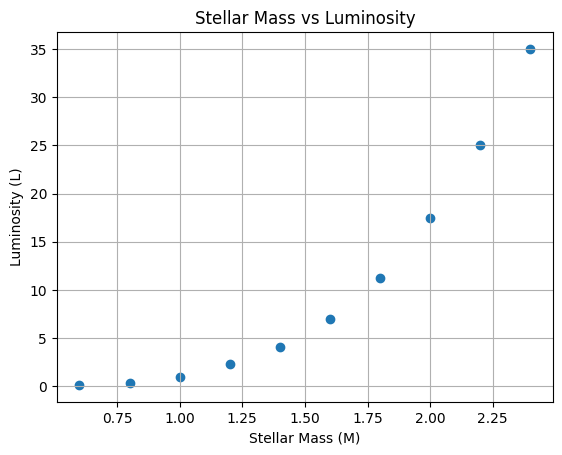

In [5]:
plt.figure()
plt.scatter(M, L)
plt.xlabel("Stellar Mass (M)")
plt.ylabel("Luminosity (L)")
plt.title("Stellar Mass vs Luminosity")
plt.grid(True)
plt.show()


## 3. Model Definition and Loss Function

In this part, we explicitly define:

The hypothesis function:

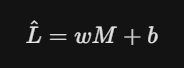

The loss function, using Mean Squared Error (MSE).

The MSE measures the average squared difference between predicted and actual luminosity values and serves as the objective function to be minimized during training.

This step formalizes the regression problem mathematically.

In [ ]:
def predict(M, w, b):
    return w * M + b

def mse_loss(M, L, w, b):
    total_error = 0.0
    for i in range(len(M)):
        y_hat = w * M[i] + b
        total_error += (y_hat - L[i])**2
    return total_error / len(M)


4. Cost Surface Visualization J(w,b)

Here we evaluate the cost function over a grid of values for w and b.
For each pair (w,b), we compute the MSE and store it.

The resulting contour plot represents the cost surface, where each point corresponds to a specific model configuration.
The minimum of this surface represents the optimal parameters that best fit the data.

This visualization helps build intuition about optimization and why gradient descent is effective.

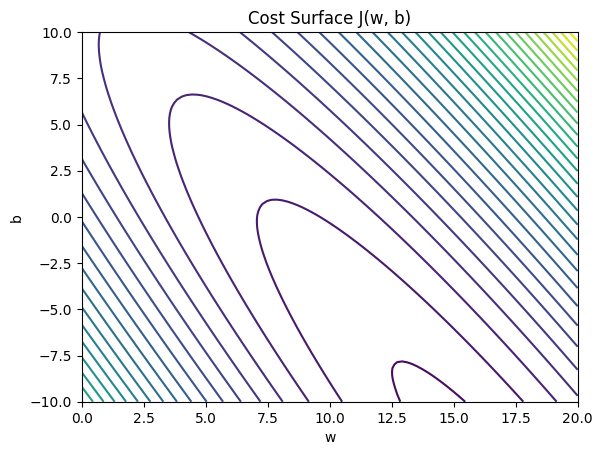

In [9]:
w_vals = np.linspace(0, 20, 100)
b_vals = np.linspace(-10, 10, 100)

J = np.zeros((len(w_vals), len(b_vals)))

for i in range(len(w_vals)):
    for j in range(len(b_vals)):
        J[i, j] = mse_loss(M, L, w_vals[i], b_vals[j])


W, B = np.meshgrid(w_vals, b_vals)

plt.figure()
plt.contour(W, B, J.T, levels=30)
plt.xlabel("w")
plt.ylabel("b")
plt.title("Cost Surface J(w, b)")
plt.show()



5. Gradient Derivation

In this section, we derive the analytical gradients of the loss function with respect to the parameters:

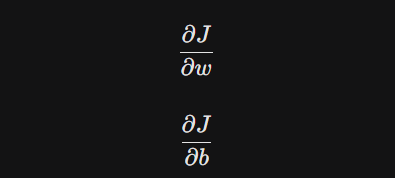

These gradients quantify how the loss changes when the parameters change and are essential for implementing gradient descent from first principles.

## 6. Gradient Descent (Non-Vectorized Implementation)

Here we implement gradient descent using explicit loops over the dataset.
Each sample contributes individually to the gradient computation.

This implementation is intentionally simple and explicit, making the learning process transparent and easier to understand, even though it is computationally less efficient.


In [10]:
def gradient_descent_loop(M, L, lr, epochs):
    w = 0.0
    b = 0.0
    loss_history = []

    for _ in range(epochs):
        dw = 0.0
        db = 0.0

        for i in range(len(M)):
            y_hat = w * M[i] + b
            error = y_hat - L[i]
            dw += error * M[i]
            db += error

        dw = (2 / len(M)) * dw
        db = (2 / len(M)) * db

        w -= lr * dw
        b -= lr * db

        loss_history.append(mse_loss(M, L, w, b))

    return w, b, loss_history


## 7. Gradient Descent (Vectorized Implementation)

In this part, we reimplement gradient descent using NumPy vectorization.
All operations are performed on arrays rather than individual samples.

This approach is mathematically equivalent to the loop-based version but is significantly more efficient and closer to how real-world machine learning systems are implemented.

In [11]:
def gradient_descent_vectorized(M, L, lr, epochs):
    w = 0.0
    b = 0.0
    loss_history = []

    for _ in range(epochs):
        y_hat = w * M + b
        error = y_hat - L

        dw = (2 / len(M)) * np.sum(error * M)
        db = (2 / len(M)) * np.sum(error)

        w -= lr * dw
        b -= lr * db

        loss_history.append(np.mean(error**2))

    return w, b, loss_history


## 8. Convergence Analysis

We plot the value of the loss function as a function of the number of iterations.
This allows us to observe how the model improves during training.

A smooth, decreasing curve indicates stable convergence, while oscillations or divergence would suggest an inappropriate learning rate.

This step is critical for diagnosing optimization behavior.

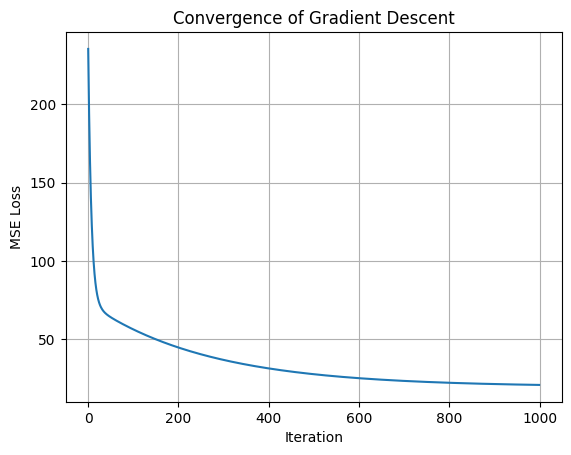

In [12]:
w, b, loss = gradient_descent_vectorized(M, L, lr=0.01, epochs=1000)

plt.figure()
plt.plot(loss)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Convergence of Gradient Descent")
plt.grid(True)
plt.show()


## 9. Learning Rate Experiments

Here we train the model using multiple learning rates.
For each learning rate, we report:

-Final values of w and b

-Final loss value

This experiment demonstrates how the learning rate affects convergence speed and stability, highlighting the trade-off between slow learning and potential divergence.

In [13]:
learning_rates = [0.001, 0.01, 0.05]

for lr in learning_rates:
    w, b, loss = gradient_descent_vectorized(M, L, lr, 1000)
    print(f"lr={lr} -> w={w:.3f}, b={b:.3f}, final loss={loss[-1]:.3f}")


lr=0.001 -> w=7.956, b=0.009, final loss=56.271
lr=0.01 -> w=16.284, b=-13.776, final loss=20.804
lr=0.05 -> w=18.129, b=-16.834, final loss=19.590


## 10. Final Fit and Model Evaluation

In the final step, we plot the learned regression line on top of the original data.

This visualization allows us to assess how well the linear model captures the data trend.
Systematic errors, especially at higher masses, indicate that a linear model is insufficient to fully represent the underlying astrophysical relationship.

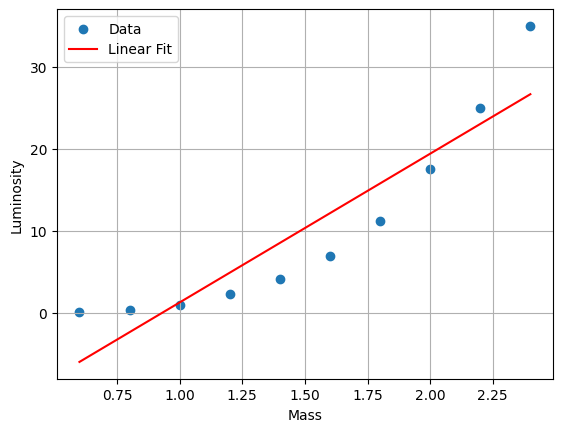

In [14]:
plt.figure()
plt.scatter(M, L, label="Data")
plt.plot(M, predict(M, w, b), color="red", label="Linear Fit")
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.legend()
plt.grid(True)
plt.show()


## 11. Conceptual Questions
Astrophysical Meaning of w

The parameter w represents how much stellar luminosity changes, on average, when the stellar mass increases. It describes the strength of the relationship between mass and luminosity in the linear model. However, it should be seen only as an approximation, not as a true physical constant.

Why Is a Linear Model Limited Here?

A linear model is limited because the relationship between stellar mass and luminosity is not linear in reality. Luminosity increases much faster than mass, especially for larger stars. As a result, the linear model produces systematic errors and cannot accurately capture the behavior of high-mass stars.